In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

Random_state = 42

In [5]:
path = r'C:\Users\asus\Desktop\Titanic_Spaceship'

sample_submission = pd.read_csv(rf'{path}\sample_submission.csv')
train = pd.read_csv(rf'{path}\train.csv')
test  = pd.read_csv(rf'{path}\test.csv')

In [6]:
train_cop = train.copy()
test_cop  = test.copy()

In [7]:
train_cop.head(5)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [8]:
train[['Cabin_deck', 'Cabin_num', 'Cabin_side']] = train['Cabin'].str.split('/', expand=True)
test[['Cabin_deck', 'Cabin_num', 'Cabin_side']] = test['Cabin'].str.split('/', expand=True)
test.drop('Cabin',axis=1, inplace=True)
train.drop('Cabin', axis=1, inplace=True)
train.head(5)

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Cabin_deck,Cabin_num,Cabin_side
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0,P
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0,S
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0,S
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0,S
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1,S


In [9]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Cabin_deck      199
Cabin_num       199
Cabin_side      199
dtype: int64

In [10]:
train['CryoSleep'] = train['CryoSleep'].fillna(False).astype(int)
train['VIP'] = train['VIP'].fillna(False).astype(int)
test['CryoSleep'] = test['CryoSleep'].fillna(False).astype(int)
test['VIP'] = test['VIP'].fillna(False).astype(int)

train['Transported'] = train['Transported'].astype(int)
train.head(5)

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Cabin_deck,Cabin_num,Cabin_side
0,0001_01,Europa,0,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0,B,0,P
1,0002_01,Earth,0,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1,F,0,S
2,0003_01,Europa,0,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0,A,0,S
3,0003_02,Europa,0,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0,A,0,S
4,0004_01,Earth,0,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1,F,1,S


In [11]:
train.drop('Name', axis=1, inplace=True)
test.drop('Name', axis=1, inplace=True)

In [12]:
train.head(5)

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin_deck,Cabin_num,Cabin_side
0,0001_01,Europa,0,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,0,B,0,P
1,0002_01,Earth,0,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,1,F,0,S
2,0003_01,Europa,0,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,A,0,S
3,0003_02,Europa,0,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,A,0,S
4,0004_01,Earth,0,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,1,F,1,S


Как будто можно разделить Passengerld на первые четыре цифры и последние две. Вот как раз последние две как я понимаю это группа, скорее всего пропадает либо всяя группа либо никто, проверим эту гипотезу и заменим столбец, если она подтвердится

all_transported     2552
none_transported    2868
mixed                797
dtype: int64

Доля групп где все вместе: 87.18%


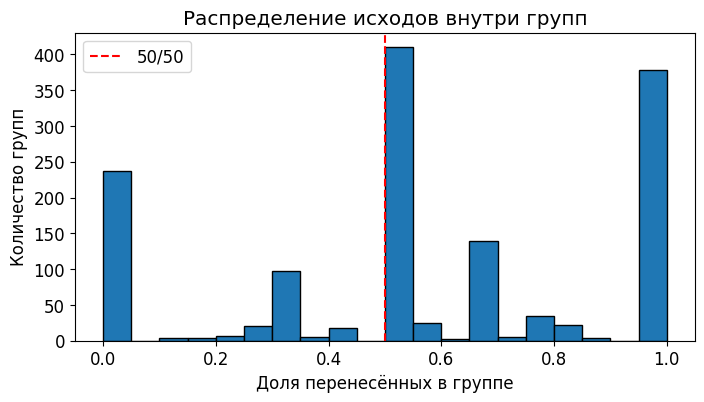

In [13]:
train['Group'] = train['PassengerId'].str.split('_').str[0]
train['Group_size'] = train.groupby('Group')['Group'].transform('count')
test['Group'] = test['PassengerId'].str.split('_').str[0]

group_stats = train.groupby('Group')['Transported'].agg(['mean', 'count'])
group_stats['all_transported'] = group_stats['mean'] == 1.0
group_stats['none_transported'] = group_stats['mean'] == 0.0
group_stats['mixed'] = (group_stats['mean'] > 0) & (group_stats['mean'] < 1)

print(group_stats[['all_transported', 'none_transported', 'mixed']].sum())
print(f"\nДоля групп где все вместе: {(group_stats['all_transported'] | group_stats['none_transported']).mean():.2%}")

multi = group_stats[group_stats['count'] > 1]

plt.figure(figsize=(8, 4))
plt.hist(multi['mean'], bins=20, edgecolor='black')
plt.xlabel('Доля перенесённых в группе')
plt.ylabel('Количество групп')
plt.title('Распределение исходов внутри групп')
plt.axvline(0.5, color='red', linestyle='--', label='50/50')
plt.legend()
plt.show()

In [14]:
train['Group_size'] = train.groupby('Group')['Group'].transform('count')
train['Is_alone'] = (train['Group_size'] == 1).astype(int)
test['Group_size'] = test.groupby('Group')['Group'].transform('count')
test['Is_alone'] = (test['Group_size'] == 1).astype(int)

Посмотрим на корреляцию полученных признаков с таргетом

In [15]:
print(train.groupby('Group_size')['Transported'].mean().round(3))

print("\nОдиночки vs группы:")
print(train.groupby('Is_alone')['Transported'].mean().round(3))

print("\nКорреляция:")
print(train[['Group_size', 'Is_alone', 'Transported']].corr()['Transported'])

Group_size
1    0.452
2    0.538
3    0.593
4    0.641
5    0.592
6    0.615
7    0.541
8    0.394
Name: Transported, dtype: float64

Одиночки vs группы:
Is_alone
0    0.567
1    0.452
Name: Transported, dtype: float64

Корреляция:
Group_size     0.082644
Is_alone      -0.113792
Transported    1.000000
Name: Transported, dtype: float64


С ростом группы до 4-ёх увеличивается и вероятность исчезновения, потом она начинает падать. Одиночки реже исчезают, но не сильно. Оставим признаки и уберём id

In [16]:
test_ids = test['PassengerId'].copy()

train.drop('PassengerId', axis=1, inplace=True)
test.drop('PassengerId', axis=1, inplace=True)

In [17]:
print(train['HomePlanet'].unique())
print(train['Destination'].unique())

<ArrowStringArray>
['Europa', 'Earth', 'Mars', nan]
Length: 4, dtype: str
<ArrowStringArray>
['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e', nan]
Length: 4, dtype: str


In [18]:
print("HomePlanet пропуски vs таргет:")
print(train[train['HomePlanet'].isnull()]['Transported'].mean())

print("Destination пропуски vs таргет:")
print(train[train['Destination'].isnull()]['Transported'].mean())

HomePlanet пропуски vs таргет:
0.5124378109452736
Destination пропуски vs таргет:
0.5054945054945055


Пропуски не имеют связи с таргетом, поэтому можно их кодировать просто модой

In [19]:
train.head(5)

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin_deck,Cabin_num,Cabin_side,Group,Group_size,Is_alone
0,Europa,0,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,0,B,0,P,0001,1,1
1,Earth,0,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,1,F,0,S,0002,1,1
2,Europa,0,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,A,0,S,0003,2,0
3,Europa,0,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,A,0,S,0003,2,0
4,Earth,0,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,1,F,1,S,0004,1,1


In [20]:
home_mode = train['HomePlanet'].mode()[0]
dest_mode = train['Destination'].mode()[0]

train['HomePlanet'] = train['HomePlanet'].fillna(home_mode)
test['HomePlanet']  = test['HomePlanet'].fillna(home_mode)
train['Destination'] = train['Destination'].fillna(dest_mode)
test['Destination']  = test['Destination'].fillna(dest_mode)

train = pd.get_dummies(train, columns=['HomePlanet', 'Destination'], dtype=int)
test  = pd.get_dummies(test,  columns=['HomePlanet', 'Destination'], dtype=int)

train.head(5)

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin_deck,...,Cabin_side,Group,Group_size,Is_alone,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,B,...,P,0001,1,1,0,1,0,0,0,1
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,F,...,S,0002,1,1,1,0,0,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,A,...,S,0003,2,0,0,1,0,0,0,1
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,A,...,S,0003,2,0,0,1,0,0,0,1
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,F,...,S,0004,1,1,1,0,0,0,0,1


In [21]:
print(train.columns.tolist())

['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'Cabin_deck', 'Cabin_num', 'Cabin_side', 'Group', 'Group_size', 'Is_alone', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']


In [22]:
train[['Cabin_deck', 'Cabin_num', 'Cabin_side']].head(5)

,Cabin_deck,Cabin_num,Cabin_side
0,B,0,P
1,F,0,S
2,A,0,S
3,A,0,S
4,F,1,S


In [23]:
train.isnull().sum()

CryoSleep                      0
Age                          179
VIP                            0
RoomService                  181
FoodCourt                    183
ShoppingMall                 208
Spa                          183
VRDeck                       188
Transported                    0
Cabin_deck                   199
Cabin_num                    199
Cabin_side                   199
Group                          0
Group_size                     0
Is_alone                       0
HomePlanet_Earth               0
HomePlanet_Europa              0
HomePlanet_Mars                0
Destination_55 Cancri e        0
Destination_PSO J318.5-22      0
Destination_TRAPPIST-1e        0
dtype: int64

In [24]:
age_median = train['Age'].median()
train['Age'] = train['Age'].fillna(age_median)
test['Age']  = test['Age'].fillna(age_median)

print(train[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].median())

RoomService     0.0
FoodCourt       0.0
ShoppingMall    0.0
Spa             0.0
VRDeck          0.0
dtype: float64


In [25]:
expenses = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in expenses:
    train[col] = train[col].fillna(0)
    test[col]  = test[col].fillna(0)

In [26]:
train['Cabin_num'] = train['Cabin_num'].astype(float)
test['Cabin_num']  = test['Cabin_num'].astype(float)

cab_median = train['Cabin_num'].median()
train['Cabin_num'] = train['Cabin_num'].fillna(cab_median)
test['Cabin_num']  = test['Cabin_num'].fillna(cab_median)

deck_mode = train['Cabin_deck'].mode()[0]
side_mode = train['Cabin_side'].mode()[0]

train['Cabin_deck'] = train['Cabin_deck'].fillna(deck_mode)
test['Cabin_deck']  = test['Cabin_deck'].fillna(deck_mode)
train['Cabin_side'] = train['Cabin_side'].fillna(side_mode)
test['Cabin_side']  = test['Cabin_side'].fillna(side_mode)

In [27]:
train.head(5)

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin_deck,...,Cabin_side,Group,Group_size,Is_alone,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,B,...,P,0001,1,1,0,1,0,0,0,1
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,F,...,S,0002,1,1,1,0,0,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,A,...,S,0003,2,0,0,1,0,0,0,1
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,A,...,S,0003,2,0,0,1,0,0,0,1
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,F,...,S,0004,1,1,1,0,0,0,0,1


In [28]:
print(train['Cabin_deck'].unique())
print(train['Cabin_side'].unique())
print(train['Cabin_num'].unique())

<ArrowStringArray>
['B', 'F', 'A', 'G', 'E', 'D', 'C', 'T']
Length: 8, dtype: str
<ArrowStringArray>
['P', 'S']
Length: 2, dtype: str
[0.000e+00 1.000e+00 2.000e+00 ... 1.892e+03 1.893e+03 1.894e+03]


In [29]:
train['Cabin_num'].head(5)

0    0.0
1    0.0
2    0.0
3    0.0
4    1.0
Name: Cabin_num, dtype: float64

In [30]:
train = pd.get_dummies(train, columns=['Cabin_deck', 'Cabin_side'], dtype=int)
test  = pd.get_dummies(test,  columns=['Cabin_deck', 'Cabin_side'], dtype=int)

train.drop('Group', axis=1, inplace=True)
test.drop('Group', axis=1, inplace=True)

In [31]:
print(set(train.columns) - set(test.columns)) 
print(set(test.columns) - set(train.columns))

{'Transported'}
set()


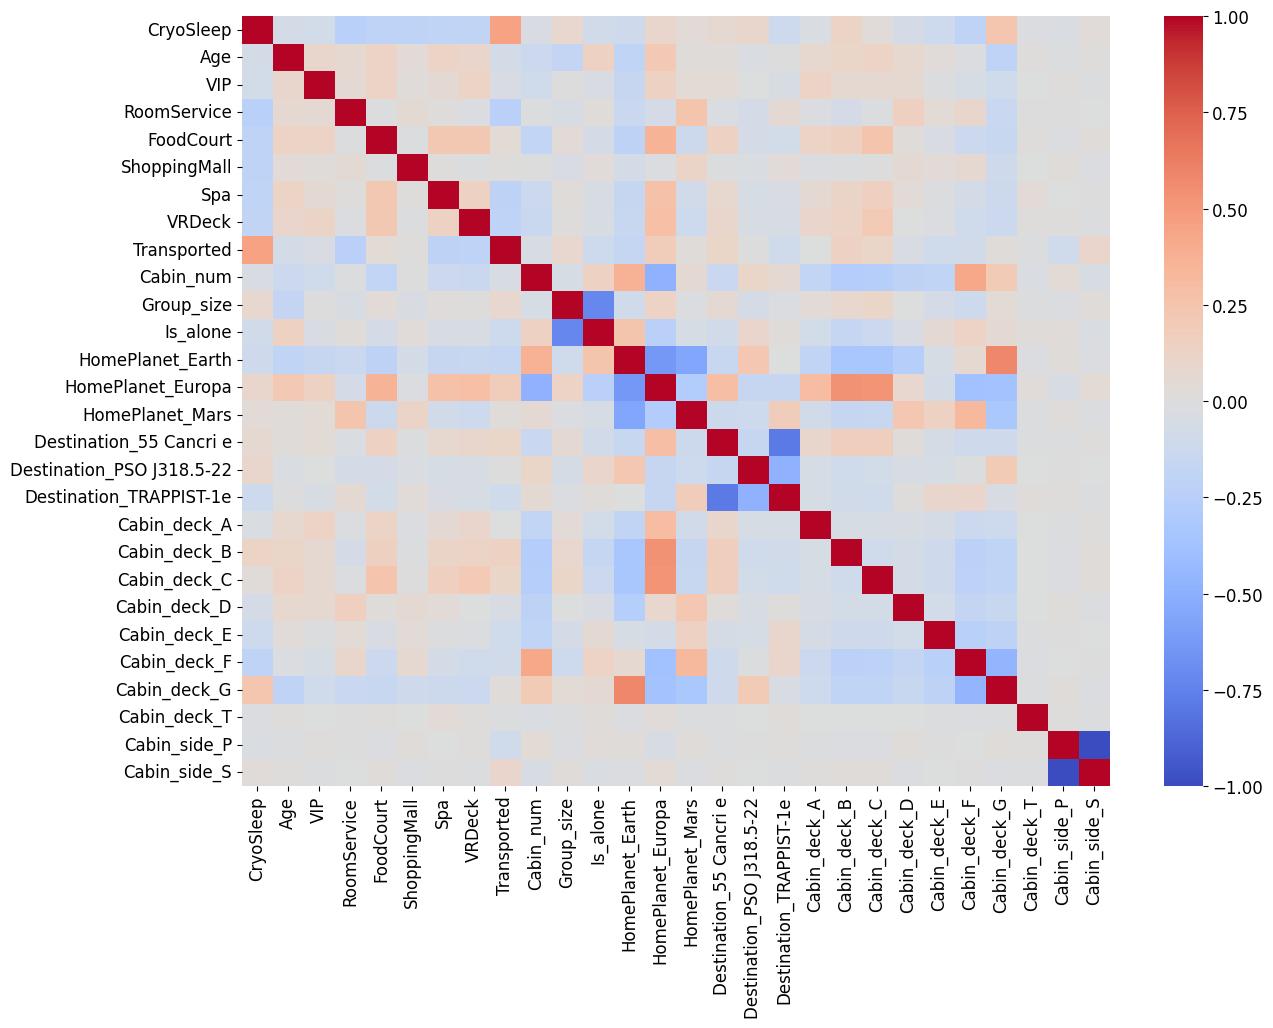

RoomService                 -0.241124
Spa                         -0.218545
VRDeck                      -0.204874
HomePlanet_Earth            -0.168845
Is_alone                    -0.113792
Cabin_side_P                -0.101397
Cabin_deck_E                -0.097965
Destination_TRAPPIST-1e     -0.096319
Cabin_deck_F                -0.086360
Age                         -0.074233
Cabin_num                   -0.044502
VIP                         -0.037261
Cabin_deck_D                -0.034046
Cabin_deck_T                -0.014568
Cabin_deck_A                -0.002623
Destination_PSO J318.5-22    0.000092
ShoppingMall                 0.009391
Cabin_deck_G                 0.016269
HomePlanet_Mars              0.019544
FoodCourt                    0.045583
Group_size                   0.082644
Cabin_side_S                 0.101397
Cabin_deck_C                 0.108193
Destination_55 Cancri e      0.108722
Cabin_deck_B                 0.144733
HomePlanet_Europa            0.176916
CryoSleep   

In [32]:
plt.figure(figsize=(14, 10))
sns.heatmap(train.corr(), annot=False, cmap='coolwarm', center=0)
plt.show()

print(train.corr()['Transported'].sort_values())

Проверим были ли люди которые были в криосне, но при этом не тратили деньги

In [33]:
anomaly = ((train['CryoSleep'] == 1) & ((train['RoomService'] > 0) | (train['ShoppingMall'] > 0) | (train['Spa'] > 0) | (train['FoodCourt'] > 0) | (train['VRDeck'] > 0))).sum()
print(f"В криосне но тратили: {anomaly}")

В криосне но тратили: 0


Отлично значит пропуски я заполнил верно. Теперь посмотрим не было ли каких-то выбросов и не нужна ли лог-трансформация каких-либо числовых признаков

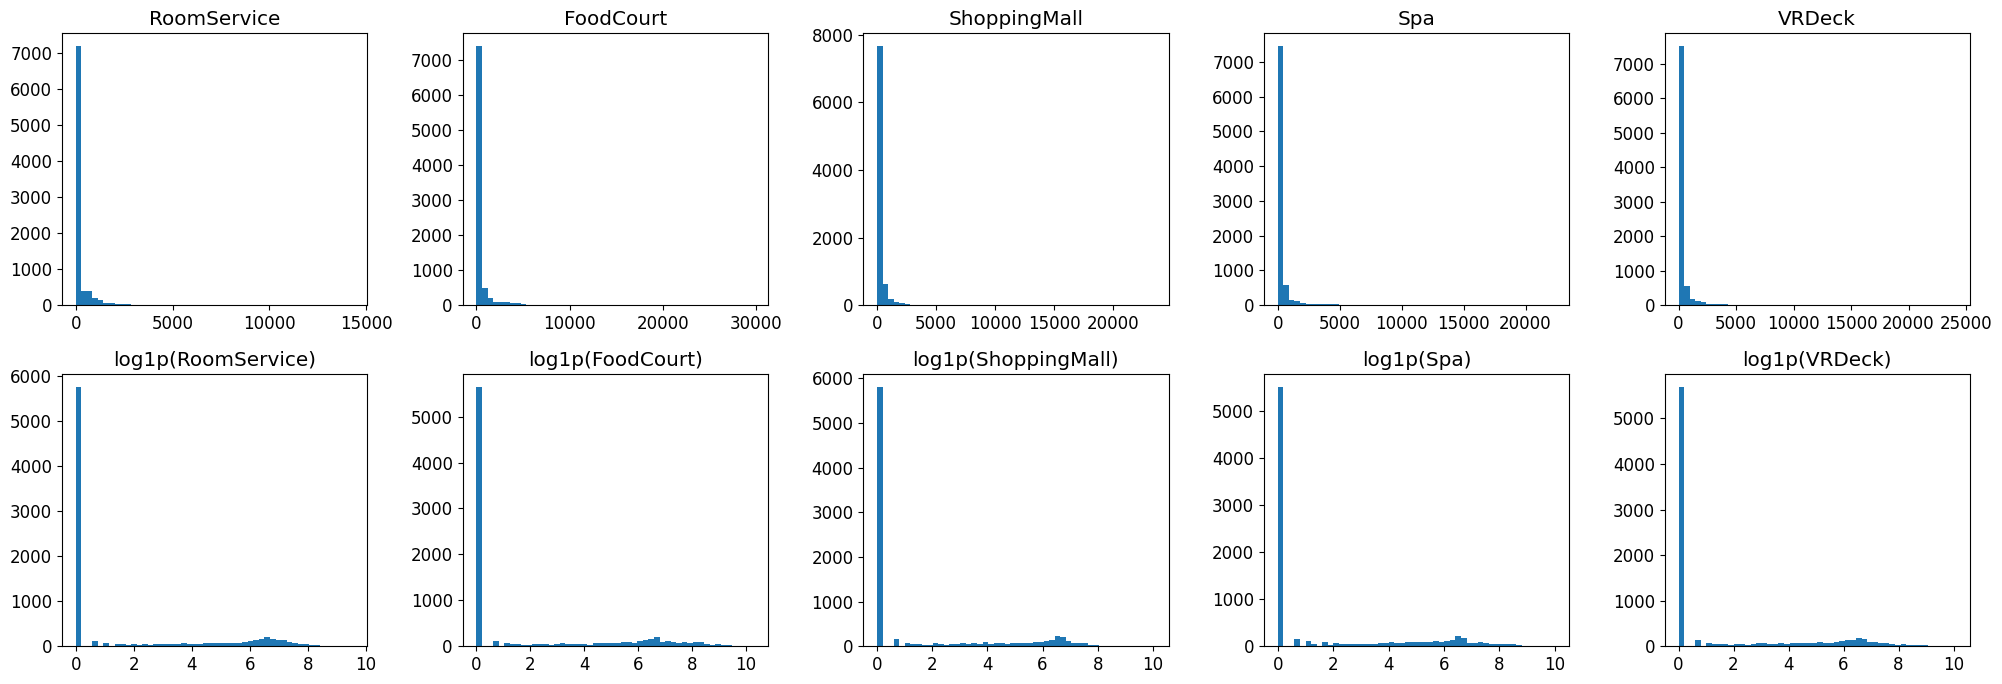

In [34]:
expenses = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))

for i, col in enumerate(expenses):
    axes[0, i].hist(train[col], bins=50)
    axes[0, i].set_title(f'{col}')

for i, col in enumerate(expenses):
    axes[1, i].hist(np.log1p(train[col]), bins=50)
    axes[1, i].set_title(f'log1p({col})')

plt.tight_layout()
plt.show()

Для стекинга, если буду реализовывать линейные модели, нужно будет логарифмировать эти признаки, так как они приближают распределение к нормальному. Теперь сделаю LightGBM без подбора гиперпараметров как baseline

In [35]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

X = train.drop(['Transported'], axis=1)
y = train['Transported']

model = LGBMClassifier(random_state=42, verbose=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print(f'CV accuracy: {scores.mean():.4f} +- {scores.std():.4f}')

CV accuracy: 0.8080 +- 0.0024


In [36]:
train.head(5)

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin_num,...,Cabin_deck_A,Cabin_deck_B,Cabin_deck_C,Cabin_deck_D,Cabin_deck_E,Cabin_deck_F,Cabin_deck_G,Cabin_deck_T,Cabin_side_P,Cabin_side_S
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0,1,0,0,0,0,0,0,1,0
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,0.0,...,0,0,0,0,0,1,0,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,1.0,...,0,0,0,0,0,1,0,0,0,1


Два признака мы уже создали, проверим ещё влияние нескольких синтетических признаков на таргет по их корреляции (буду использовать корреляцию как Пирсона, так и Спирмена, чтобы можно было зафиксировать нелинейную связь)

In [37]:
tmp = pd.DataFrame()
tmp['Total_expenses'] = train[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)
tmp['Is_spending']    = (tmp['Total_expenses'] > 0).astype(int)
tmp['Is_child']       = (train['Age'] < 13).astype(int)
tmp['Luxury']         = train[['Spa','VRDeck','RoomService']].sum(axis=1)
tmp['Basic']          = train[['FoodCourt','ShoppingMall']].sum(axis=1)
tmp['Transported']    = train['Transported']

print("Пирсон:")
print(tmp.corr(method='pearson')['Transported'].sort_values())

print("\nСпирмен:")
print(tmp.corr(method='spearman')['Transported'].sort_values())

Пирсон:
Is_spending      -0.481628
Luxury           -0.348244
Total_expenses   -0.199514
Basic             0.046189
Is_child          0.125399
Transported       1.000000
Name: Transported, dtype: float64

Спирмен:
Luxury           -0.553782
Is_spending      -0.481628
Total_expenses   -0.419474
Basic            -0.247317
Is_child          0.125399
Transported       1.000000
Name: Transported, dtype: float64


In [38]:
print(train['CryoSleep'].corr((train[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1) == 0).astype(int)))

0.8607125346344519


По итогу хорошо коррелирующими с таргетом и при этом не дублирующими уже существующие оказались: Luxury/Basic, Is_child. Проверим насколько они бы улучшили предсказание относительно baseline и примем финальное решение стоит ли их включать

In [39]:
for df in [train, test]:
    raw_exp = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
    df['Luxury']  = df[['Spa','VRDeck','RoomService']].sum(axis=1)
    df['Basic']   = df[['FoodCourt','ShoppingMall']].sum(axis=1)
    df['Is_child'] = (df['Age'] < 13).astype(int)

X = train.drop('Transported', axis=1)
y = train['Transported']

scores_2 = cross_val_score(LGBMClassifier(random_state=42, verbose=-1), X, y, cv=cv, scoring='accuracy')
print(f"С новыми признаками: {scores_2.mean():.4f} (было 0.8080)")

С новыми признаками: 0.8097 (было 0.8080)


In [40]:
!pip install optuna

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 10.0),
        'random_state': 42,
        'verbose': -1
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    return scores.mean()

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nЛучший accuracy: {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

[I 2026-08-02 13:32:42,902] A new study created in memory with name: no-name-8dfff07a-c85b-490b-8d30-66bfd74b6308
Best trial: 0. Best value: 0.808581:   1%|          | 1/100 [00:03<05:48,  3.52s/it]

[I 2026-08-02 13:32:46,424] Trial 0 finished with value: 0.8085810463402707 and parameters: {'n_estimators': 962, 'learning_rate': 0.012923064876329146, 'num_leaves': 97, 'max_depth': 5, 'min_child_samples': 72, 'subsample': 0.6412314072302183, 'colsample_bytree': 0.6248155775256298, 'reg_alpha': 2.3449606065327746, 'reg_lambda': 2.207644485256121}. Best is trial 0 with value: 0.8085810463402707.


Best trial: 1. Best value: 0.809501:   2%|▏         | 2/100 [00:04<02:55,  1.79s/it]

[I 2026-08-02 13:32:47,003] Trial 1 finished with value: 0.8095010491724739 and parameters: {'n_estimators': 115, 'learning_rate': 0.18657753595827165, 'num_leaves': 103, 'max_depth': 9, 'min_child_samples': 66, 'subsample': 0.8061805959369085, 'colsample_bytree': 0.8374054440670312, 'reg_alpha': 8.142067623895857, 'reg_lambda': 7.917190156472475}. Best is trial 1 with value: 0.8095010491724739.


Best trial: 1. Best value: 0.809501:   3%|▎         | 3/100 [00:05<02:27,  1.52s/it]

...

[I 2026-08-02 13:36:58,191] Trial 97 finished with value: 0.8105365238411293 and parameters: {'n_estimators': 405, 'learning_rate': 0.12864733945488507, 'num_leaves': 118, 'max_depth': 9, 'min_child_samples': 78, 'subsample': 0.7063463187668043, 'colsample_bytree': 0.7911380959231115, 'reg_alpha': 8.04317181290408, 'reg_lambda': 9.111026618410142}. Best is trial 96 with value: 0.8121469754650471.


Best trial: 96. Best value: 0.812147:  99%|█████████▉| 99/100 [04:16<00:01,  1.37s/it]

[I 2026-08-02 13:36:59,273] Trial 98 finished with value: 0.8097316619805174 and parameters: {'n_estimators': 343, 'learning_rate': 0.14839416347597797, 'num_leaves': 102, 'max_depth': 8, 'min_child_samples': 82, 'subsample': 0.7125767347000603, 'colsample_bytree': 0.7745056828038412, 'reg_alpha': 8.318647305295139, 'reg_lambda': 9.557999940134891}. Best is trial 96 with value: 0.8121469754650471.


Best trial: 96. Best value: 0.812147: 100%|██████████| 100/100 [04:18<00:00,  2.58s/it]

[I 2026-08-02 13:37:00,972] Trial 99 finished with value: 0.810536060630324 and parameters: {'n_estimators': 374, 'learning_rate': 0.10793725154883767, 'num_leaves': 108, 'max_depth': 9, 'min_child_samples': 25, 'subsample': 0.6859340160702978, 'colsample_bytree': 0.733594158518722, 'reg_alpha': 6.986965239230343, 'reg_lambda': 8.726403191709144}. Best is trial 96 with value: 0.8121469754650471.

Лучший accuracy: 0.8121
Лучшие параметры: {'n_estimators': 413, 'learning_rate': 0.1267988757025619, 'num_leaves': 108, 'max_depth': 9, 'min_child_samples': 26, 'subsample': 0.711366501133205, 'colsample_bytree': 0.7311023280156977, 'reg_alpha': 7.925904820778094, 'reg_lambda': 8.80597443272751}


Теперь сделаем стекинг и посмотрим насколько увеличится accuracy

In [42]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
from sklearn.ensemble import StackingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=15))
])

base_models = [
    ('lgbm', LGBMClassifier(**study.best_params, random_state=42, verbose=-1)),
    ('catboost', CatBoostClassifier(verbose=0, random_state=42)),
    ('knn', knn_pipe)
]

meta_model = LogisticRegression(max_iter=1000)

stack = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(stack, X, y, cv=cv, scoring='accuracy')
print(f"Стекинг CV: {scores.mean():.4f} (было 0.8120)")

Стекинг CV: 0.8133 (было 0.8120)


Затюним ещё KNN, CatBoost и так должен быть хорош

In [44]:
for k in [5, 10, 15, 20, 30, 50]:
    knn_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(knn_pipe, X, y, cv=cv, scoring='accuracy')
    print(f"k={k}: {scores.mean():.4f}")

k=5: 0.7730
k=10: 0.7741
k=15: 0.7784
k=20: 0.7738
k=30: 0.7748
k=50: 0.7687


И так я выбрал лучший

По итогу лучший результат по трейну 0.8133, засабмитим и посмотрим что будет на тесте

In [45]:
stack.fit(X, y)
preds = stack.predict(test)

submission = pd.DataFrame({'PassengerId': test_ids,'Transported': preds.astype(bool)})
submission.to_csv('submission.csv', index=False)
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


In [46]:
print(submission.shape)
print(submission['Transported'].dtype)
print(submission['Transported'].value_counts())

(4277, 2)
bool
Transported
True     2175
False    2102
Name: count, dtype: int64


Попробуем ещё на всякий случай weigthed voiting, хоть я уже и засабмитил

In [51]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('lgbm', LGBMClassifier(**study.best_params, random_state=42, verbose=-1)),
        ('catboost', CatBoostClassifier(verbose=0, random_state=42)),
        ('knn', knn_pipe)
    ],
    voting='soft',
    weights=[2, 2, 1]
)

scores = cross_val_score(voting, X, y, cv=cv, scoring='accuracy')
print(f"Voting: {scores.mean():.4f} (стекинг был 0.8133)")

Voting: 0.8128 (стекинг был 0.8133)


Нет weighted voiting хуже, значит дело в feature_engineering